# Analyse results from Pypsa-Earth
This notebook reads the latest optimization described in the config.yaml file and makes plots and summaries of the results.

Sources: 
- Plot capacity - map view: https://github.com/pypsa-meets-earth/documentation/blob/main/notebooks/viz/regional_transm_system_viz.ipynb
- Analyse energy potential: https://github.com/pypsa-meets-earth/documentation/blob/main/notebooks/build_renewable_profiles.ipynb
- Analyse energy generation: https://pypsa.readthedocs.io/en/latest/examples/statistics.html

Some files are needed:
* PyPSA network file (e.g. "elec.nc" contains a lot of details and looks perfect)
* a country shape file (may be found in "resources/shapes/country_shapes.geojson")
* a renewable profile file (may be found in "resources/renewable_profiles/....nc)

## Import packages

In [97]:
import yaml
import pypsa
import warnings
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
import pandas as pd
from pathlib import Path
import seaborn as sns
from datetime import datetime
from cartopy import crs as ccrs
from pypsa.plot import add_legend_circles, add_legend_lines, add_legend_patches
import os
import xarray as xr
import cartopy

In [98]:
warnings.simplefilter(action='ignore', category=FutureWarning)
# change current directory to parent folder
if not os.path.isdir("pypsa-earth"):
    os.chdir("../..")

PARENT = os.path.realpath("pypsa-earth/") + "/"
# Specify config name
# CONFIG = "config-EG-sec-2050-0_50_100_200_300_400_800_1000TWh"
CONFIG = "config-EG-50percentCO2-2050-50-1000TWh"
config = yaml.safe_load(open(PARENT + "own-configs/" + CONFIG + ".yaml"))

# Specify name for figures
overall_name = 'v2_EG_CO2-50perc-reduc_300TWh'
# Specify of you want to save the figures
save_figs = True

In [117]:
run_name = config["run"]["name"]
run_sector_name = config["run"]["sector_name"]                          
simpl = config["scenario"]["simpl"]    
clust = config["scenario"]["clusters"]   
ll = config["scenario"]["ll"]             
load_scale = config["load_options"]["scale"]               
opts = config["scenario"]["opts"]       
sopts = config["scenario"]["sopts"]              
planning = config["scenario"]["planning_horizons"]        
discountrate = config["costs"]["discountrate"]                
demand = config["scenario"]["demand"]                  
# export_value = config["export"]["h2export"]  
export_value = [300]                

# Process each setting into a string representation 
simpl_str = "_".join(map(str, simpl))   
clust_str = "_".join(map(str, clust))    
ll_str = "l" + "_".join(map(str, ll))           
scale_str = f"lc{load_scale}"                           
opts_str = "_".join(map(str, opts))    
sopts_str = "_".join(map(str, sopts))                 
planning_str = "_".join(map(str, planning))               
dr_str = "_".join(map(str, discountrate))             
demand_str = "_".join(map(str, demand))                    
export_str = "_".join(map(str, export_value)) + "export"

scenario_subpath = f"{run_name}/" if run_name else ""

nc_file_name = (
    f"elec_s_{clust_str}_ec_{ll_str}_{opts_str}_{sopts_str}_"
    f"{planning_str}_{dr_str}_{demand_str}_{export_str}.nc"
)

# Network file
network_path = PARENT + f"networks/{scenario_subpath}elec.nc"

# Country shape file
regions_onshore_path = PARENT + f"resources/{scenario_subpath}shapes/country_shapes.geojson"

# Bus_regions_file
bus_regions = PARENT + f"resources/{scenario_subpath}bus_regions/regions_onshore.geojson"

# GADM shapes file
gadm_shapes_path = PARENT + f"resources/{scenario_subpath}/shapes/gadm_shapes.geojson"

# Results path
results_path = PARENT + f"results/{run_sector_name}/postnetworks/{nc_file_name}"

# Renewable profile file
solar_path = PARENT + f"resources/{scenario_subpath}renewable_profiles/profile_solar.nc"
onwind_path = PARENT + f"resources/{scenario_subpath}renewable_profiles/profile_onwind.nc"

## Analysis Network Setup

In [118]:
warnings.simplefilter(action='ignore', category=FutureWarning)
n = pypsa.Network(results_path)
regions_onshore = gpd.read_file(regions_onshore_path)
bus_regions = gpd.read_file(bus_regions)
# New
gadm_shapes = gpd.read_file(gadm_shapes_path)
country_coordinates = regions_onshore.total_bounds[[0, 2, 1, 3]]
warnings.simplefilter(action='default', category=FutureWarning)

Index(['CO2 pipeline EG.10_1_AC <-> EG.18_1_AC',
       'CO2 pipeline EG.10_1_AC <-> EG.19_1_AC',
       'CO2 pipeline EG.10_1_AC <-> EG.2_1_AC',
       'CO2 pipeline EG.10_1_AC <-> EG.8_1_AC',
       'CO2 pipeline EG.11_1_AC <-> EG.12_1_AC',
       'CO2 pipeline EG.11_1_AC <-> EG.15_1_AC',
       'CO2 pipeline EG.11_1_AC <-> EG.16_1_AC',
       'CO2 pipeline EG.11_1_AC <-> EG.19_1_AC',
       'CO2 pipeline EG.11_1_AC <-> EG.8_1_AC',
       'CO2 pipeline EG.12_1_AC <-> EG.16_1_AC',
       'CO2 pipeline EG.12_1_AC <-> EG.1_1_AC',
       'CO2 pipeline EG.12_1_AC <-> EG.5_1_AC',
       'CO2 pipeline EG.12_1_AC <-> EG.8_1_AC',
       'CO2 pipeline EG.12_1_AC <-> EG.9_1_AC',
       'CO2 pipeline EG.13_1_AC <-> EG.25_1_AC',
       'CO2 pipeline EG.14_1_AC <-> EG.17_1_AC',
       'CO2 pipeline EG.14_1_AC <-> EG.25_1_AC',
       'CO2 pipeline EG.15_1_AC <-> EG.19_1_AC',
       'CO2 pipeline EG.15_1_AC <-> EG.22_1_AC',
       'CO2 pipeline EG.15_1_AC <-> EG.26_1_AC',
       'CO2 pipeline EG.15_

## Data import check

Plot of the region of interest

In [101]:
# fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.EqualEarth(n.buses.x.mean())})
# with plt.rc_context({"patch.linewidth": 0.}):
#     regions_onshore.plot(
#     ax=ax,
#     facecolor="green",
#     edgecolor="white",
#     aspect="equal",
#     transform=ccrs.PlateCarree(),
#     linewidth=0,
#     )
# ax.set_title(", ".join(regions_onshore.name.values))

List number of components by type

In [102]:
for c in n.iterate_components(list(n.components.keys())[2:]):
    print("Component '{}' has {} entries".format(c.name,len(c.df)))

Component 'Bus' has 574 entries
Component 'Carrier' has 38 entries
Component 'GlobalConstraint' has 1 entries
Component 'Line' has 56 entries
Component 'LineType' has 35 entries
Component 'TransformerType' has 14 entries
Component 'Link' has 1517 entries
Component 'Load' has 795 entries
Component 'Generator' has 912 entries
Component 'StorageUnit' has 3 entries
Component 'Store' has 355 entries


List the snapshots of the PyPSA network

In [103]:
print(n.snapshots)
print(f"Time steps: " + str(len(n.snapshots)))

DatetimeIndex(['2013-01-01 00:00:00', '2013-01-01 03:00:00',
               '2013-01-01 06:00:00', '2013-01-01 09:00:00',
               '2013-01-01 12:00:00', '2013-01-01 15:00:00',
               '2013-01-01 18:00:00', '2013-01-01 21:00:00',
               '2013-01-02 00:00:00', '2013-01-02 03:00:00',
               ...
               '2013-12-30 18:00:00', '2013-12-30 21:00:00',
               '2013-12-31 00:00:00', '2013-12-31 03:00:00',
               '2013-12-31 06:00:00', '2013-12-31 09:00:00',
               '2013-12-31 12:00:00', '2013-12-31 15:00:00',
               '2013-12-31 18:00:00', '2013-12-31 21:00:00'],
              dtype='datetime64[ns]', name='snapshot', length=2920, freq=None)
Time steps: 2920


## Analyse energy system

In [104]:
n.carriers.loc[n.carriers.color.isnull() | (n.carriers.color == "#11111"), "color"] = "#d3d3d3"
n.carriers.color

Carrier
CCGT                                         #b80404
nuclear                                      #ff9000
geothermal                                   #ba91b1
hydro                                        #08ad97
offwind-ac                                   #6895dd
offwind-dc                                   #74c6f2
onwind                                       #235ebc
solar                                        #f9d002
PHS                                          #08ad97
ror                                          #4adbc8
co2                                                 
gas                                                 
oil                                                 
coal                                                
lignite                                             
biomass                                             
H2                                                  
battery                                             
residential rural heat                

### Analyse the current capacity of the energy system - map view

Set relevant carriers and colors

In [105]:
# TODO: Ensure that every carrier has a color and a nice name in the config, then we can delete this code cell
# --- Ensure all carriers have color and nice_name ---
missing_carriers = [
    'lignite', 'coal', 'solar rooftop', 'oil', 'gas',
    'residential rural solar thermal',
    'residential urban decentral solar thermal',
    'services rural solar thermal',
    'services urban decentral solar thermal',
    'urban central solar thermal',
    'ccgt'
]

carrier_color_mapping = {
    'lignite': 'coal',
    'solar rooftop': 'solar',
    'residential rural solar thermal': 'solar',
    'residential urban decentral solar thermal': 'solar',
    'services rural solar thermal': 'solar',
    'services urban decentral solar thermal': 'solar',
    'urban central solar thermal': 'solar',
    'ccgt': 'gas'
}

# Assign colors for missing carriers
for c, ref in carrier_color_mapping.items():
    n.carriers.loc[c, 'color'] = n.carriers.loc[ref, 'color']

# Set nice_names
n.carriers.loc['coal', 'nice_name'] = 'Coal'
n.carriers.loc['oil', 'nice_name'] = 'Oil'
n.carriers.loc['ccgt', 'nice_name'] = 'Gas'

for c, ref in carrier_color_mapping.items():
    if c not in ['ccgt']:  # ccgt already has its own name
        n.carriers.loc[c, 'nice_name'] = n.carriers.loc[ref, 'nice_name']

Do the plotting

/opt/miniconda3/envs/pypsa-earth/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


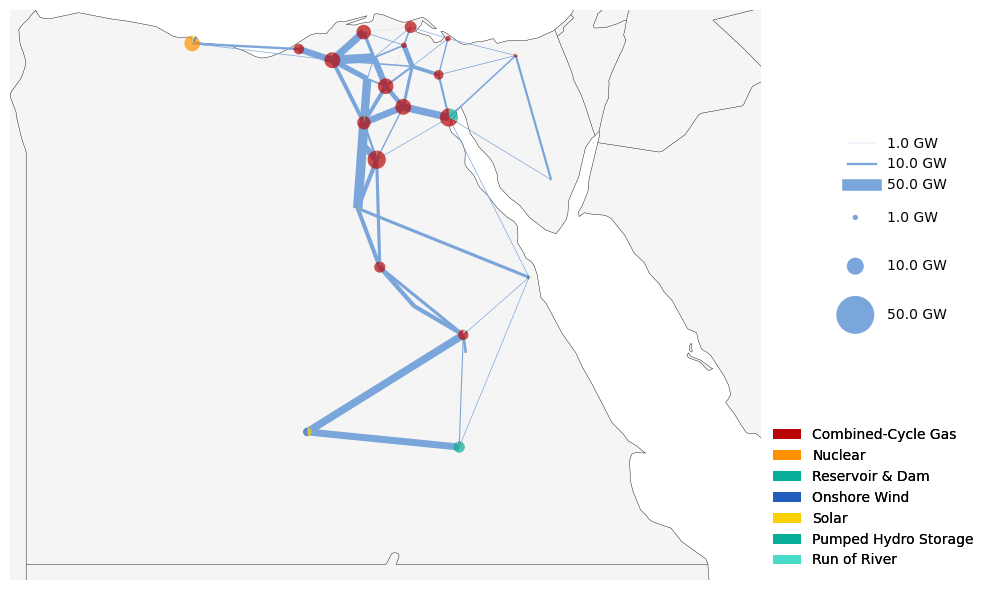

In [106]:
# Scale settings
bus_scale = 3e5 
line_scale = 6e3
link_scale = 6e25

bus_sizes = [1000, 10000, 50000]  # in MW
line_sizes = [1000, 10000, 50000]  # in MW

# --- Remove "Load" carrier for plotting ---
if "Load" in n.carriers.index:
    n.carriers.drop("Load", inplace=True)

# --- Aggregate generator and storage capacities by bus and carrier ---
gen = n.generators[n.generators.carrier != "load"].groupby(["bus", "carrier"]).p_nom.sum()
sto = n.storage_units.groupby(["bus", "carrier"]).p_nom.sum()
buses = pd.concat([gen, sto])

# --- Plotting ---
fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={"projection": ccrs.PlateCarree()})

# --- Filter Links: only those that lie within GADM regions ---
# Extract the base part of the bus names
link_bus0_base = n.links.bus0.str.split("_AC").str[0]
link_bus1_base = n.links.bus1.str.split("_AC").str[0]

# Keep only links whose both ends are present in the GADM shapes
valid_links = n.links[
    link_bus0_base.isin(gadm_shapes.index) &
    link_bus1_base.isin(gadm_shapes.index) &
    (n.links.p_nom > 0)  # optional: only positive capacity
]

# overwrite temporarily for the plot
links_backup = n.links
n.links = valid_links

with plt.rc_context({"patch.linewidth": 0.}):
    n.plot(
        bus_sizes=buses / bus_scale,
        bus_alpha=0.7,
        line_widths=n.lines.s_nom / line_scale,
        link_widths=n.links.p_nom / line_scale,
        line_colors="#7ba6db",
        ax=ax,
        margin=0.4,
        color_geomap={'ocean': 'white', 'land': 'whitesmoke'},
    )

# Set plot bounds (custom for Egypt)
bounds = regions_onshore.total_bounds.copy()
pad_x = 2 # expansion to the east
bounds[2] += pad_x  # expand east
ax.set_extent(bounds[[0, 2, 1, 3]])

legend_kwargs = {"loc": "upper left", "frameon": False}
legend_circles_dict = {"bbox_to_anchor": (1.1, 0.67), "labelspacing": 2.5, **legend_kwargs}

add_legend_circles(
    ax,
    [s / bus_scale for s in bus_sizes],
    [f"{s / 1000} GW" for s in bus_sizes],
    patch_kw={'facecolor':'#7ba6db'},
    legend_kw=legend_circles_dict,    
)
add_legend_lines(
    ax,
    [s / line_scale for s in line_sizes],
    [f"{s / 1000} GW" for s in line_sizes],
    colors=["#7ba6db"] * len(line_sizes),
    legend_kw={"bbox_to_anchor": (1.1, 0.8), **legend_kwargs},
)

# --- Create patch legend for carriers (unique nice_name, non-zero capacity) ---
colors_legend = []
labels_legend = []
seen = set()
for c in n.carriers.index:
    name = n.carriers.loc[c, 'nice_name']
    color = n.carriers.loc[c, 'color']

    # Sum capacity over all buses for this carrier
    if c in buses.index.get_level_values('carrier'):
        val_total = buses.xs(c, level='carrier').sum()
    else:
        val_total = 0

    if name not in seen and val_total > 0:
        seen.add(name)
        colors_legend.append(color)
        labels_legend.append(name)

add_legend_patches(
    ax,
    colors_legend,
    labels_legend,
    legend_kw={"bbox_to_anchor": (1, 0), **legend_kwargs, "loc": "lower left"},
)

fig.tight_layout()

# Ensure the directory exists
output_dir = f"pypsa-earth-docu/results/EG/graphics_general/"
os.makedirs(output_dir, exist_ok=True)

# Save figure without white borders
if save_figs:
    filename = f"{output_dir}{overall_name}_brownfield_network.pdf"
    plt.savefig(filename, bbox_inches='tight', dpi=300)
    filename_png = filename.replace('.pdf', '.png')
    plt.savefig(filename_png, bbox_inches='tight', dpi=300)

plt.show()

<Axes: xlabel='Line'>

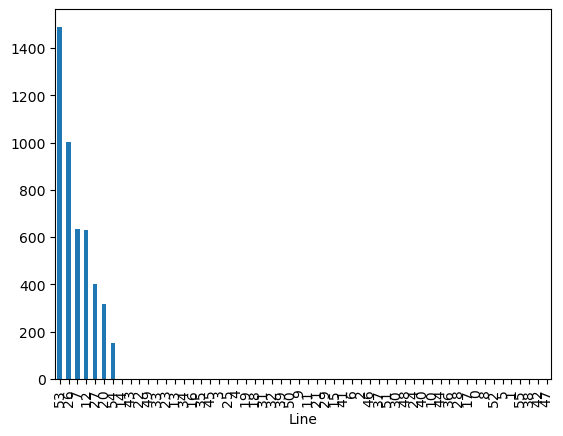

In [107]:
(n.lines.s_nom_opt - n.lines.s_nom).sort_values(ascending=False).plot(kind='bar')

Analyse the current generation capacity of the energy system - pie chart view

Text(0.5, 1.0, 'Generator Capacity by Carrier (GW)')

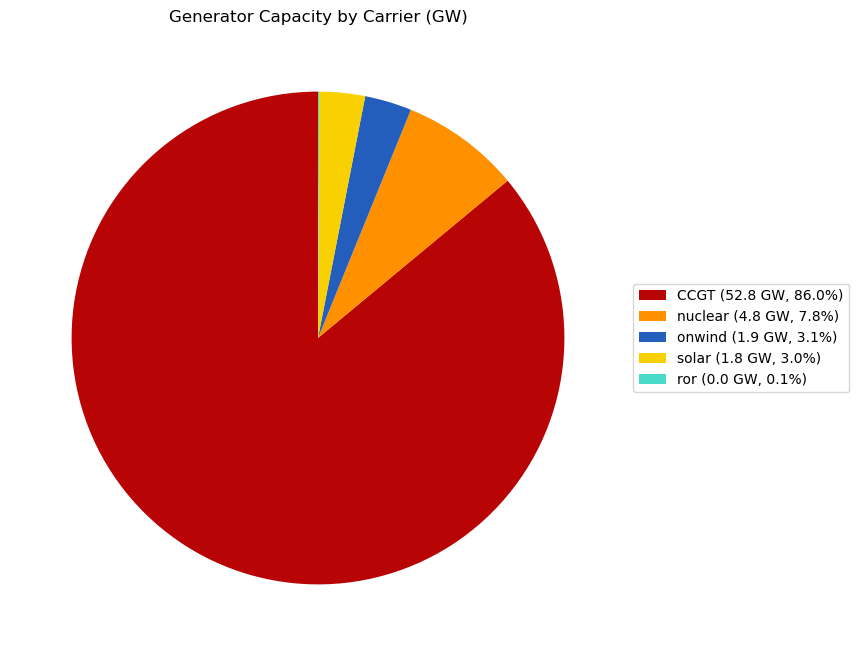

In [108]:
# --- Extract data for current energy carriers ---
generator_capacity_by_carrier = (
    n.generators[~n.generators.carrier.str.contains("load", case=False)]
    .groupby("carrier")
    .p_nom.sum()
    .div(1e3)  # Convert to GW
    .sort_values(ascending=False)
)
# --- Filter: keep only entries > 0 ---
generator_capacity_by_carrier = generator_capacity_by_carrier[generator_capacity_by_carrier > 0]

plt.figure(figsize=(8, 8))
wedges, _ = plt.pie(
    generator_capacity_by_carrier,
    labels=None,   # no labels directly in the chart
    startangle=90,
    colors=n.carriers[
            n.carriers.index.isin(generator_capacity_by_carrier.index)
        ].color.reindex(generator_capacity_by_carrier.index)
)
# Legend with capacity + share
labels = [
    f"{c} ({v:.1f} GW, {100*v/generator_capacity_by_carrier.sum():.1f}%)"
    for c, v in zip(generator_capacity_by_carrier.index, generator_capacity_by_carrier.values)
]
plt.legend(
    wedges,
    labels,
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)
plt.title("Generator Capacity by Carrier (GW)")

Analyse the current generation capacity of the energy system - tabular view

In [109]:
generator_capacity_by_carrier # already in GW

carrier
CCGT       52.764200
nuclear     4.800000
onwind      1.889971
solar       1.836000
ror         0.047323
Name: p_nom, dtype: float64

Analyse the future capacity of the energy system - map view

<Axes: xlabel='bus,carrier'>

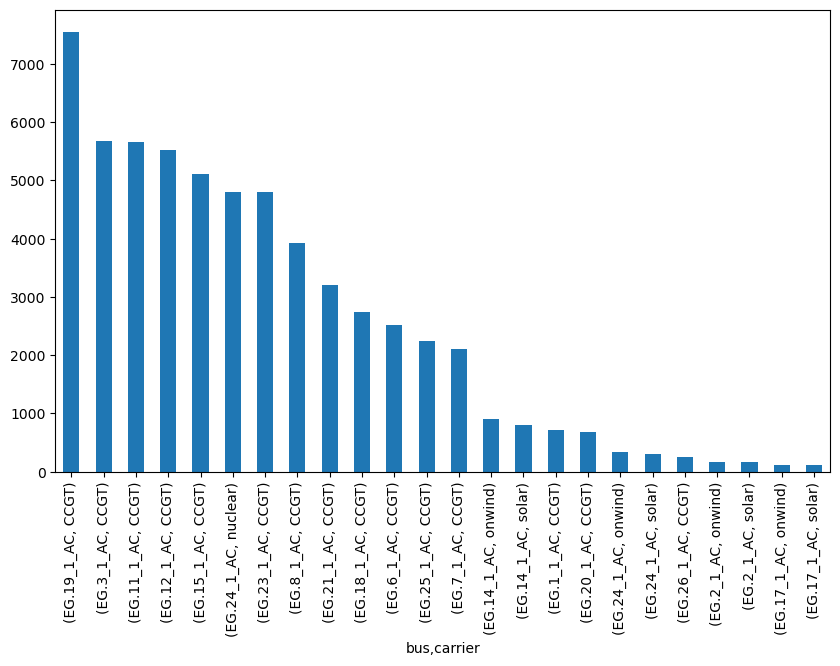

In [110]:
gen[gen > 100].sort_values(ascending=False).plot(kind='bar', figsize=(10, 6))

### Analyse the future capacity of the energy system - map view

Add missing colors

In [111]:
# TODO: Ensure that every carrier has a color and a nice name in the config, then we can delete this code cell
mask_name = n.carriers["nice_name"].isna() | (n.carriers["nice_name"] == "")
n.carriers.loc[mask_name, "nice_name"] = n.carriers.index[mask_name].str.capitalize()

mask_color = n.carriers["color"].isna() | (n.carriers["color"] == "")
n.carriers.loc[mask_color, "color"] = "gray"

Plot the network

/opt/miniconda3/envs/pypsa-earth/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


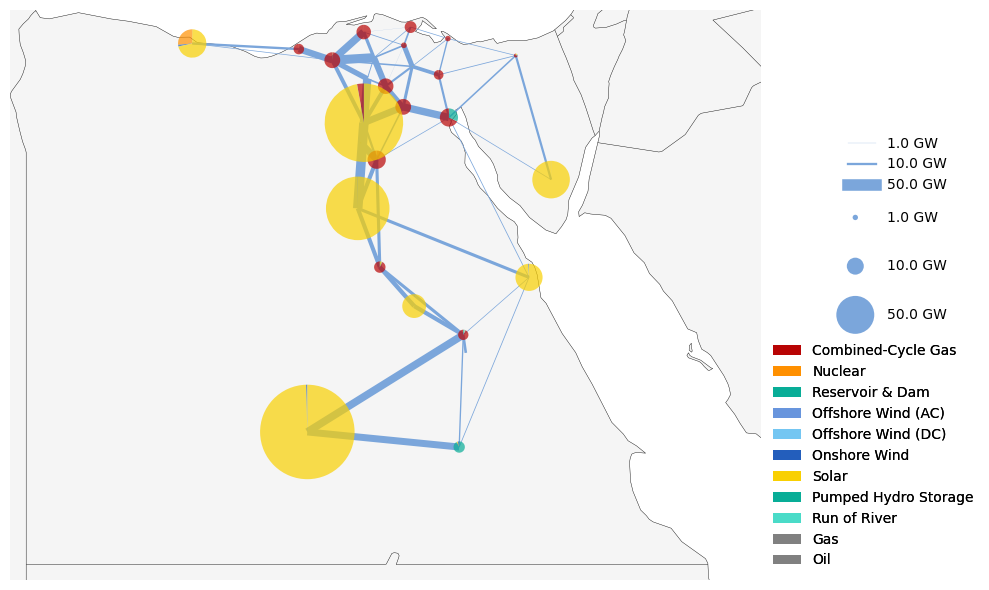

In [112]:
# Scale settings
bus_scale = 3e5 
line_scale = 6e3
link_scale = 6e25

bus_sizes = [1000, 10000, 50000]  # in MW
line_sizes = [1000, 10000, 50000]  # in MW

# --- Remove "Load" carrier for plotting ---
if "Load" in n.carriers.index:
    n.carriers.drop("Load", inplace=True)

# --- Aggregate generator and storage capacities by bus and carrier ---
gen = n.generators[n.generators.carrier != "load"].groupby(["bus", "carrier"]).p_nom_opt.sum()
sto = n.storage_units.groupby(["bus", "carrier"]).p_nom_opt.sum()
buses = pd.concat([gen, sto])

# --- Plotting ---
fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={"projection": ccrs.PlateCarree()})

# --- Filter Links: only those that lie within GADM regions ---
# Extract the base part of the bus names
link_bus0_base = n.links.bus0.str.split("_AC").str[0]
link_bus1_base = n.links.bus1.str.split("_AC").str[0]

# Keep only links whose both ends are present in the GADM shapes
valid_links = n.links[
    link_bus0_base.isin(gadm_shapes.index) &
    link_bus1_base.isin(gadm_shapes.index) &
    (n.links.p_nom > 0)  # optional: only positive capacity
]

# overwrite temporarily for the plot
links_backup = n.links
n.links = valid_links

with plt.rc_context({"patch.linewidth": 0.}):
    n.plot(
        bus_sizes=buses / bus_scale,
        bus_alpha=0.7,
        line_widths=n.lines.s_nom_opt / line_scale,
        link_widths=n.links.p_nom_opt / line_scale,
        line_colors="#7ba6db",
        ax=ax,
        margin=0.4,
        color_geomap={'ocean': 'white', 'land': 'whitesmoke'},
    )

# Set plot bounds (custom for Egypt)
bounds = regions_onshore.total_bounds.copy()
pad_x = 2 # expansion to the east
bounds[2] += pad_x  # expand east
ax.set_extent(bounds[[0, 2, 1, 3]])

legend_kwargs = {"loc": "upper left", "frameon": False}
legend_circles_dict = {"bbox_to_anchor": (1.1, 0.67), "labelspacing": 2.5, **legend_kwargs}

add_legend_circles(
    ax,
    [s / bus_scale for s in bus_sizes],
    [f"{s / 1000} GW" for s in bus_sizes],
    patch_kw={'facecolor':'#7ba6db'},
    legend_kw=legend_circles_dict,    
)
add_legend_lines(
    ax,
    [s / line_scale for s in line_sizes],
    [f"{s / 1000} GW" for s in line_sizes],
    colors=["#7ba6db"] * len(line_sizes),
    legend_kw={"bbox_to_anchor": (1.1, 0.8), **legend_kwargs},
)

# --- Create patch legend for carriers (unique nice_name, non-zero capacity) ---
colors_legend = []
labels_legend = []
seen = set()
for c in n.carriers.index:
    name = n.carriers.loc[c, 'nice_name']
    color = n.carriers.loc[c, 'color']

    # Sum capacity over all buses for this carrier
    if c in buses.index.get_level_values('carrier'):
        val_total = buses.xs(c, level='carrier').sum()
    else:
        val_total = 0

    if name not in seen and val_total > 0:
        seen.add(name)
        colors_legend.append(color)
        labels_legend.append(name)

add_legend_patches(
    ax,
    colors_legend,
    labels_legend,
    legend_kw={"bbox_to_anchor": (1, 0), **legend_kwargs, "loc": "lower left"},
)

fig.tight_layout()

# Ensure the directory exists
output_dir = f"pypsa-earth-docu/results/EG/graphics_general/"
os.makedirs(output_dir, exist_ok=True)

# Save figure without white borders
if save_figs:
    filename = f"{output_dir}{overall_name}_optimized_network.pdf"
    plt.savefig(filename, bbox_inches='tight', dpi=300)
    filename_png = filename.replace('.pdf', '.png')
    plt.savefig(filename_png, bbox_inches='tight', dpi=300)

plt.show()

Analyse grid expansion

/opt/miniconda3/envs/pypsa-earth/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


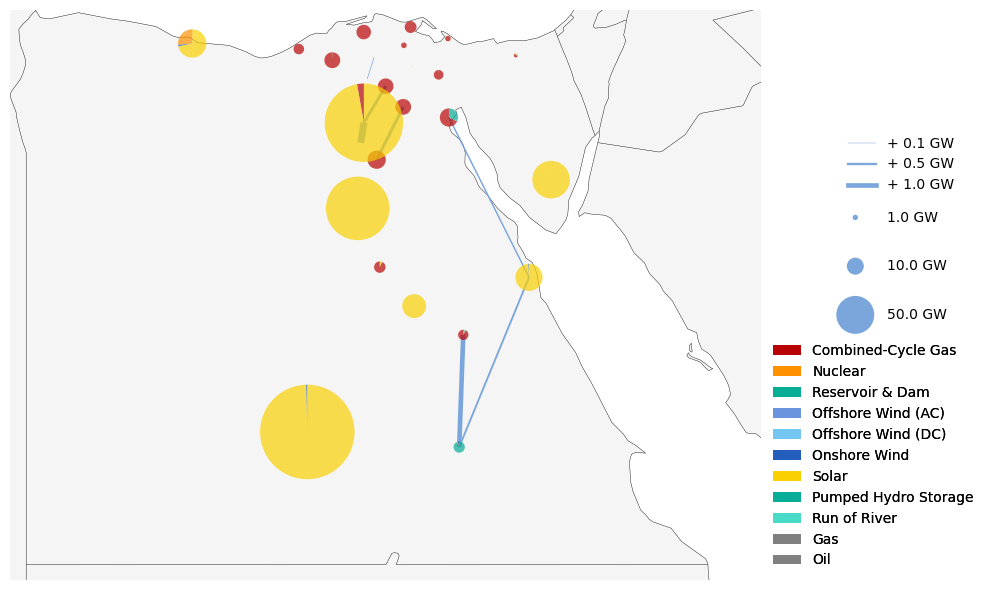

In [113]:
# Scale settings
bus_scale = 3e5 
line_scale = 3e2
link_scale = 6e25

bus_sizes = [1000, 10000, 50000]  # in MW
line_sizes = [100, 500, 1000]  # in MW

# --- Remove "Load" carrier for plotting ---
if "Load" in n.carriers.index:
    n.carriers.drop("Load", inplace=True)

# --- Aggregate generator and storage capacities by bus and carrier ---
gen = n.generators[n.generators.carrier != "load"].groupby(["bus", "carrier"]).p_nom_opt.sum()
sto = n.storage_units.groupby(["bus", "carrier"]).p_nom_opt.sum()
buses = pd.concat([gen, sto])

# --- Plotting ---
fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={"projection": ccrs.PlateCarree()})

# --- Filter Links: only those that lie within GADM regions ---
# Extract the base part of the bus names
link_bus0_base = n.links.bus0.str.split("_AC").str[0]
link_bus1_base = n.links.bus1.str.split("_AC").str[0]

# Keep only links whose both ends are present in the GADM shapes
valid_links = n.links[
    link_bus0_base.isin(gadm_shapes.index) &
    link_bus1_base.isin(gadm_shapes.index) &
    (n.links.p_nom > 0)  # optional: only positive capacity
]

# overwrite temporarily for the plot
links_backup = n.links
n.links = valid_links

with plt.rc_context({"patch.linewidth": 0.}):
    n.plot(
        bus_sizes=buses / bus_scale,
        bus_alpha=0.7,
        line_widths=(n.lines.s_nom_opt - n.lines.s_nom) / line_scale,
        # link_widths=n.links.p_nom / line_scale,
        link_widths=0,
        line_colors="#7ba6db",
        ax=ax,
        margin=0.4,
        color_geomap={'ocean': 'white', 'land': 'whitesmoke'},
    )

# Set plot bounds (custom for Egypt)
bounds = regions_onshore.total_bounds.copy()
pad_x = 2 # expansion to the east
bounds[2] += pad_x  # expand east
ax.set_extent(bounds[[0, 2, 1, 3]])

legend_kwargs = {"loc": "upper left", "frameon": False}
legend_circles_dict = {"bbox_to_anchor": (1.1, 0.67), "labelspacing": 2.5, **legend_kwargs}

add_legend_circles(
    ax,
    [s / bus_scale for s in bus_sizes],
    [f"{s / 1000} GW" for s in bus_sizes],
    patch_kw={'facecolor':'#7ba6db'},
    legend_kw=legend_circles_dict,    
)
add_legend_lines(
    ax,
    [s / line_scale for s in line_sizes],
    [f"+ {s / 1000} GW" for s in line_sizes],
    colors=["#7ba6db"] * len(line_sizes),
    legend_kw={"bbox_to_anchor": (1.1, 0.8), **legend_kwargs},
)

# --- Create patch legend for carriers (unique nice_name, non-zero capacity) ---
colors_legend = []
labels_legend = []
seen = set()
for c in n.carriers.index:
    name = n.carriers.loc[c, 'nice_name']
    color = n.carriers.loc[c, 'color']

    # Sum capacity over all buses for this carrier
    if c in buses.index.get_level_values('carrier'):
        val_total = buses.xs(c, level='carrier').sum()
    else:
        val_total = 0

    if name not in seen and val_total > 0:
        seen.add(name)
        colors_legend.append(color)
        labels_legend.append(name)

add_legend_patches(
    ax,
    colors_legend,
    labels_legend,
    legend_kw={"bbox_to_anchor": (1, 0), **legend_kwargs, "loc": "lower left"},
)

fig.tight_layout()

# Ensure the directory exists
output_dir = f"pypsa-earth-docu/results/EG/graphics_general/"
os.makedirs(output_dir, exist_ok=True)

# Save figure without white borders
if save_figs:
    filename = f"{output_dir}{overall_name}_optimized_network_GridExpansion.pdf"
    plt.savefig(filename, bbox_inches='tight', dpi=300)
    filename_png = filename.replace('.pdf', '.png')
    plt.savefig(filename_png, bbox_inches='tight', dpi=300)

plt.show()

## Plot multiple

In [119]:
# Assuming your .nc files live in elec_dir
elec_dir = "pypsa-earth/results/EG-sec-WS/postnetworks/"

# Collect all the .nc files
nc_files = [
    "elec_s_8_ec_lcopt_Co2L0-3H_24H_2050_0.071_NZ_0export.nc",
    "elec_s_8_ec_lcopt_Co2L0-3H_24H_2050_0.071_NZ_107export.nc",
    "elec_s_8_ec_lcopt_Co2L0.1-3H_24H_2050_0.071_NZ_0export.nc",
    "elec_s_8_ec_lcopt_Co2L0.1-3H_24H_2050_0.071_NZ_107export.nc",
    "elec_s_8_ec_lcopt_Co2L0.2-3H_24H_2050_0.071_NZ_0export.nc",
    "elec_s_8_ec_lcopt_Co2L0.2-3H_24H_2050_0.071_NZ_107export.nc",
    "elec_s_8_ec_lcopt_Co2L0.5-3H_24H_2050_0.071_NZ_0export.nc",
    "elec_s_8_ec_lcopt_Co2L0.5-3H_24H_2050_0.071_NZ_107export.nc",
    "elec_s_8_ec_lcopt_Co2L0.7-3H_24H_2050_0.071_NZ_0export.nc",
    "elec_s_8_ec_lcopt_Co2L0.7-3H_24H_2050_0.071_NZ_107export.nc",
]

# Prepare dicts
networks = {}
#regions_onshore = {}
gadm_regions = {}

# Loop and load
for f in nc_files:
    # Derive keys from filename
    base = os.path.splitext(f)[0]  # strip ".nc"
    parts = base.split("_")
    
    # Example: ["elec","s","8","ec","lcopt","Co2L0-3H","24H","2050","0.071","NZ","0export"]
    co2_policy = parts[5]   # e.g. "Co2L0.3-3H"
    export_policy = parts[-1]  # e.g. "0export" or "107export"
    
    key = co2_policy
    h2export_key = export_policy

    # Init dicts if not already
    if key not in networks:
        networks[key] = {}
        regions_onshore[key] = {}
        gadm_regions[key] = {}
    
    # Load PyPSA network
    path = os.path.join(elec_dir, f)
    networks[key][h2export_key] = pypsa.Network(path)
    
    #regions_onshore[key][h2export_key] = gpd.read_file(s["regions_onshore_path"])
    #gadm_regions[key][h2export_key] = gpd.read_file(s["gadm_path"])


Index(['CO2 pipeline EG.10_1_AC <-> EG.18_1_AC',
       'CO2 pipeline EG.10_1_AC <-> EG.19_1_AC',
       'CO2 pipeline EG.10_1_AC <-> EG.2_1_AC',
       'CO2 pipeline EG.10_1_AC <-> EG.8_1_AC',
       'CO2 pipeline EG.11_1_AC <-> EG.12_1_AC',
       'CO2 pipeline EG.11_1_AC <-> EG.15_1_AC',
       'CO2 pipeline EG.11_1_AC <-> EG.16_1_AC',
       'CO2 pipeline EG.11_1_AC <-> EG.19_1_AC',
       'CO2 pipeline EG.11_1_AC <-> EG.8_1_AC',
       'CO2 pipeline EG.12_1_AC <-> EG.16_1_AC',
       'CO2 pipeline EG.12_1_AC <-> EG.1_1_AC',
       'CO2 pipeline EG.12_1_AC <-> EG.5_1_AC',
       'CO2 pipeline EG.12_1_AC <-> EG.8_1_AC',
       'CO2 pipeline EG.12_1_AC <-> EG.9_1_AC',
       'CO2 pipeline EG.13_1_AC <-> EG.25_1_AC',
       'CO2 pipeline EG.14_1_AC <-> EG.17_1_AC',
       'CO2 pipeline EG.14_1_AC <-> EG.25_1_AC',
       'CO2 pipeline EG.15_1_AC <-> EG.19_1_AC',
       'CO2 pipeline EG.15_1_AC <-> EG.22_1_AC',
       'CO2 pipeline EG.15_1_AC <-> EG.26_1_AC',
       'CO2 pipeline EG.15_

/opt/miniconda3/envs/pypsa-earth/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/opt/miniconda3/envs/pypsa-earth/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/opt/miniconda3/envs/pypsa-earth/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/opt/miniconda3/envs/pypsa-earth/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/opt/miniconda3/envs/pypsa-earth/lib/python3

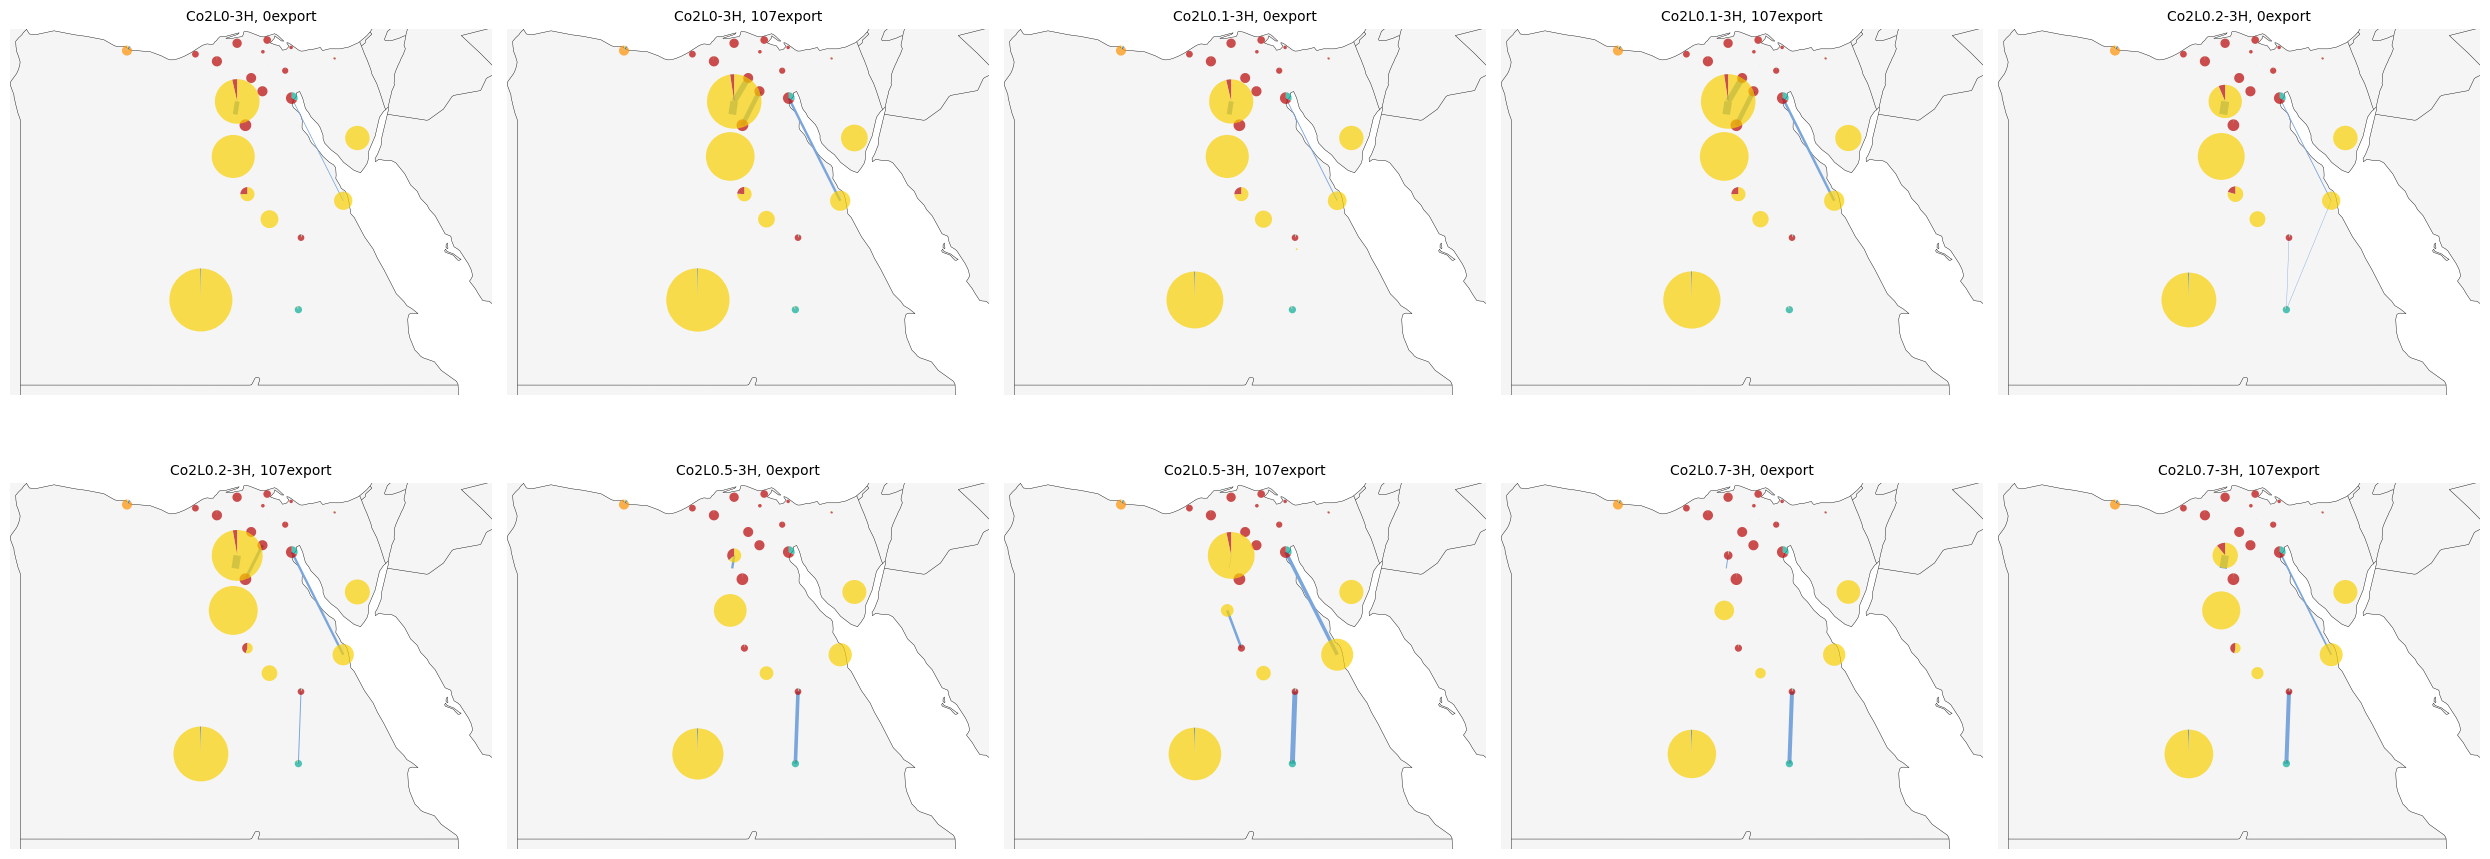

In [121]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# --- Setup subplot grid (2 x 5) ---
nrows, ncols = 2, 5
fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols,
    figsize=(5*ncols, 5*nrows),
    subplot_kw={"projection": ccrs.PlateCarree()}
)
axes = axes.flatten()

# --- Iterate over all networks in the dict ---
for i, (co2_key, export_dict) in enumerate(networks.items()):
    for j, (export_key, n) in enumerate(export_dict.items()):
        idx = i*len(export_dict) + j
        if idx >= len(axes):
            break
        ax = axes[idx]

        # --- Carrier fixes ---
        carrier_color_mapping = {
            'lignite': 'coal',
            'solar rooftop': 'solar',
            'residential rural solar thermal': 'solar',
            'residential urban decentral solar thermal': 'solar',
            'services rural solar thermal': 'solar',
            'services urban decentral solar thermal': 'solar',
            'urban central solar thermal': 'solar',
            'ccgt': 'gas'
        }

        for c, ref in carrier_color_mapping.items():
            if c in n.carriers.index and ref in n.carriers.index:
                n.carriers.loc[c, 'color'] = n.carriers.loc[ref, 'color']

        if "coal" in n.carriers.index:
            n.carriers.loc['coal', 'nice_name'] = 'Coal'
        if "oil" in n.carriers.index:
            n.carriers.loc['oil', 'nice_name'] = 'Oil'
        if "ccgt" in n.carriers.index:
            n.carriers.loc['ccgt', 'nice_name'] = 'Gas'

        for c, ref in carrier_color_mapping.items():
            if c in n.carriers.index and c != 'ccgt' and ref in n.carriers.index:
                n.carriers.loc[c, 'nice_name'] = n.carriers.loc[ref, 'nice_name']

        if "Load" in n.carriers.index:
            n.carriers.drop("Load", inplace=True)

        mask_name = n.carriers["nice_name"].isna() | (n.carriers["nice_name"] == "")
        n.carriers.loc[mask_name, "nice_name"] = n.carriers.index[mask_name].str.capitalize()
        mask_color = n.carriers["color"].isna() | (n.carriers["color"] == "")
        n.carriers.loc[mask_color, "color"] = "gray"

        # --- Capacities ---
        gen = n.generators[n.generators.carrier != "load"].groupby(["bus", "carrier"]).p_nom_opt.sum()
        sto = n.storage_units.groupby(["bus", "carrier"]).p_nom_opt.sum()
        buses = pd.concat([gen, sto])

        # --- Scale settings ---
        bus_scale = 3e5
        line_scale = 3e2
        bus_sizes = [1000, 10000, 50000]
        line_sizes = [100, 500, 1000]

        # --- Filter links ---
        link_bus0_base = n.links.bus0.str.split("_AC").str[0]
        link_bus1_base = n.links.bus1.str.split("_AC").str[0]
        valid_links = n.links[
            link_bus0_base.isin(gadm_shapes.index)
            & link_bus1_base.isin(gadm_shapes.index)
            & (n.links.p_nom > 0)
        ]

        n.links = valid_links

        missing = n.carriers[n.carriers["color"].isna() | (n.carriers["color"].str.strip() == "")]
        if not missing.empty:
            print(f"⚠️ {co2_key}/{export_key}: Missing colors for {list(missing.index)}")

        missing_carriers = set(buses.index.get_level_values("carrier")) - set(n.carriers.index)
        for c in missing_carriers:
            n.carriers.loc[c, "color"] = "gray"

        # --- Plot ---
        with plt.rc_context({"patch.linewidth": 0.}):
            n.plot(
                bus_sizes=buses / bus_scale,
                bus_alpha=0.7,
                line_widths=(n.lines.s_nom_opt - n.lines.s_nom) / line_scale,
                link_widths=0,
                line_colors="#7ba6db",
                ax=ax,
                margin=0.4,
                color_geomap={'ocean': 'white', 'land': 'whitesmoke'},
            )

        # --- Bounds ---
        bounds = regions_onshore.total_bounds.copy()
        pad_x = 2
        bounds[2] += pad_x
        ax.set_extent(bounds[[0, 2, 1, 3]])

        # --- Title per subplot ---
        ax.set_title(f"{co2_key}, {export_key}", fontsize=10)

# --- Adjust layout ---
fig.tight_layout()

# Save combined figure
output_dir = "pypsa-earth-docu/results/EG/graphics_general/"
os.makedirs(output_dir, exist_ok=True)
combined_filename = os.path.join(output_dir, "all_networks_grid.pdf")
plt.savefig(combined_filename, bbox_inches="tight", dpi=300)
plt.show()


In [122]:
networks['Co2L0.7-3H']['0export'].carriers.color

Carrier
nuclear                                      #ff9000
CCGT                                         #b80404
geothermal                                   #ba91b1
hydro                                        #08ad97
offwind-ac                                   #6895dd
offwind-dc                                   #74c6f2
onwind                                       #235ebc
solar                                        #f9d002
PHS                                          #08ad97
ror                                          #4adbc8
co2                                             gray
gas                                             gray
oil                                             gray
coal                                            gray
lignite                                         gray
biomass                                         gray
H2                                              gray
battery                                         gray
residential rural heat                

## Analyse loads (updated)

In [123]:
n.loads.carrier.unique()

array(['AC', 'residential rural heat', 'services rural heat',
       'residential urban decentral heat',
       'services urban decentral heat', 'urban central heat',
       'solid biomass for industry', 'gas for industry',
       'H2 for industry', 'naphtha for industry',
       'industry oil emissions', 'industry coal emissions',
       'low-temperature heat for industry', 'industry electricity',
       'process emissions', 'H2 for shipping', 'shipping oil',
       'shipping oil emissions', 'kerosene for aviation', 'oil emissions',
       'land transport EV', 'land transport fuel cell',
       'land transport oil', 'land transport oil emissions',
       'rail transport oil', 'rail transport electricity',
       'agriculture electricity', 'agriculture oil', 'residential oil',
       'residential biomass', 'residential gas', 'gas emissions',
       'services electricity', 'services biomass', 'services oil',
       'services gas', 'H2'], dtype=object)

/var/folders/qv/3l0ryg3j00bd0yhm6w408x1m0000gn/T/ipykernel_13557/2962364010.py:3: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby([n.loads.bus, n.loads.carrier], axis=1)


<Axes: xlabel='bus,carrier'>

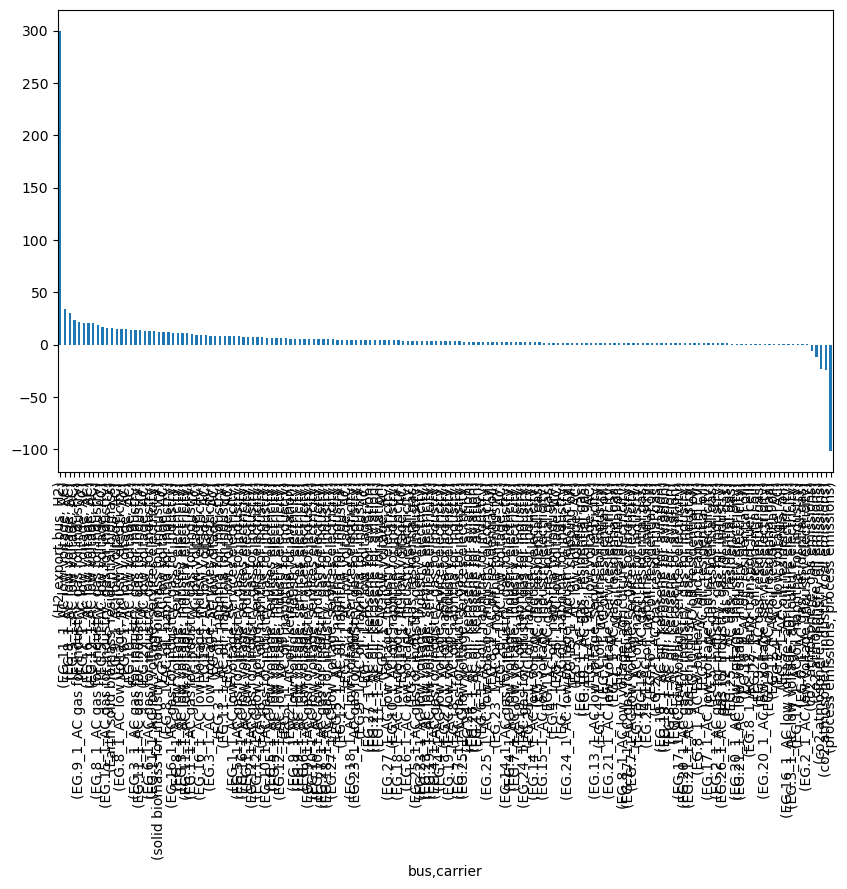

In [46]:
loads_sum = (
    n.loads_t.p
    .groupby([n.loads.bus, n.loads.carrier], axis=1)
    .sum()
    .mul(n.snapshot_weightings.generators.mean())
    .sum()
)
loads_sum[loads_sum.abs() > 1e6].divide(1e6).sort_values(ascending=False).plot(kind='bar', figsize=(10, 6))

<Axes: xlabel='carrier,bus_carrier'>

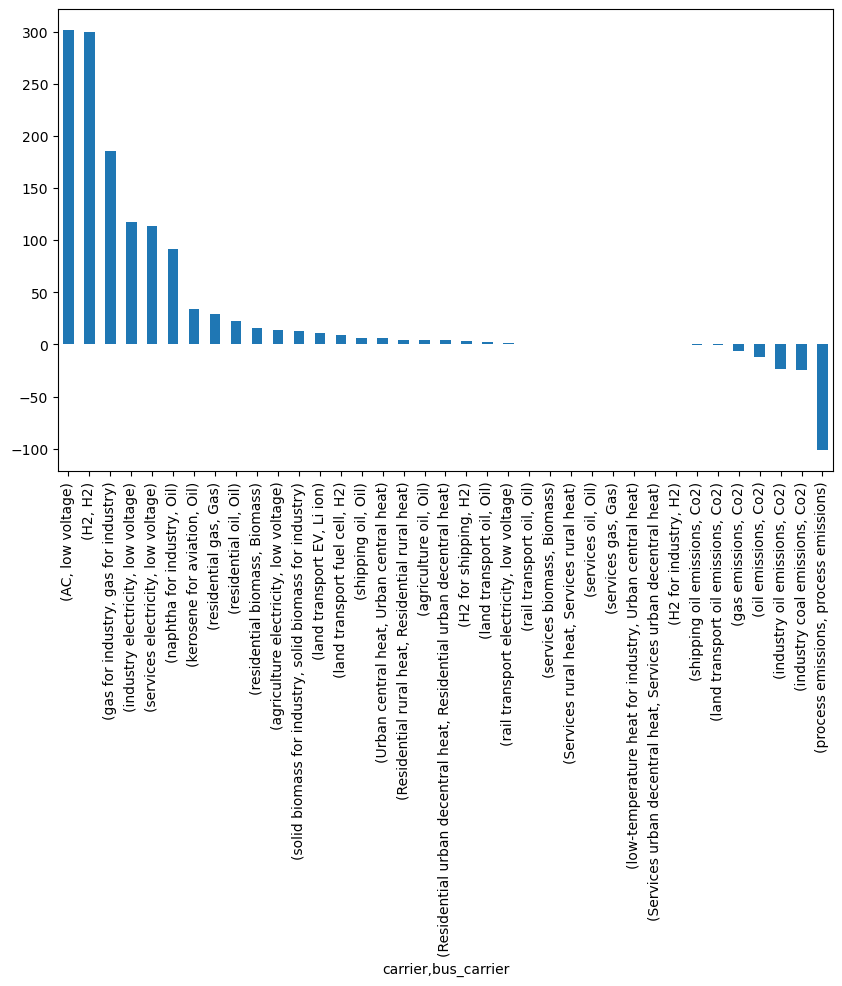

In [47]:
n.statistics.energy_balance(comps='Load').divide(-1e6).sort_values(ascending=False).plot(kind='bar', figsize=(10, 6))

<Axes: xlabel='carrier,bus_carrier'>

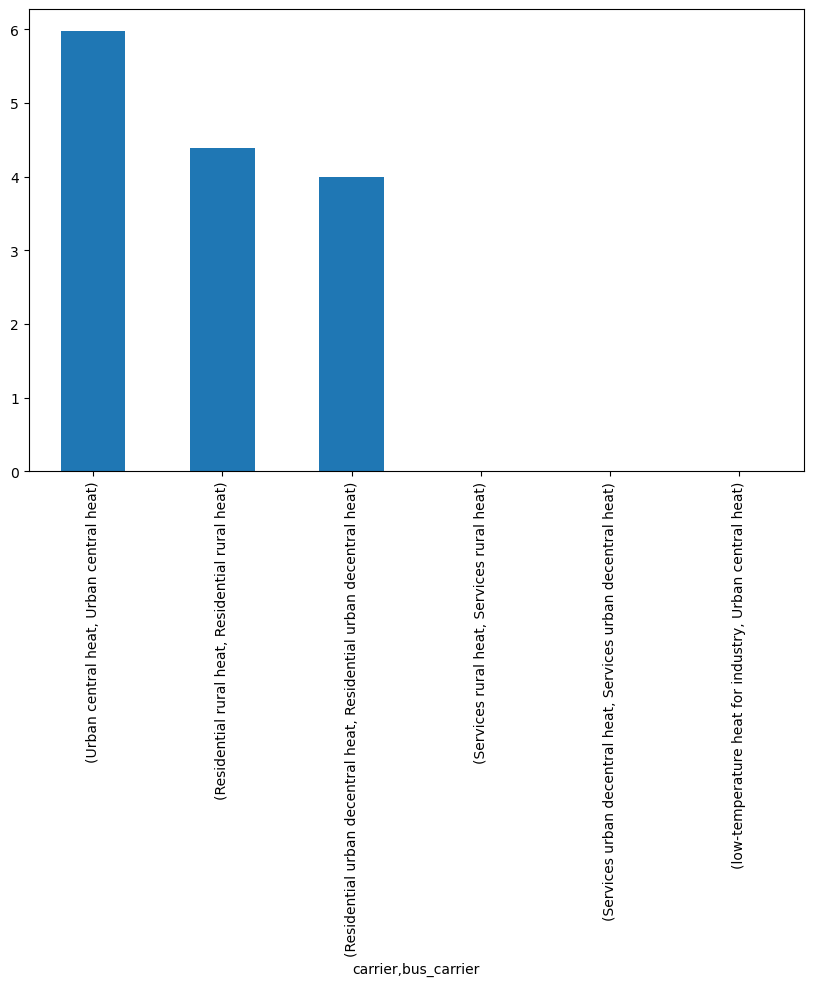

In [48]:
# Fix: Use get_level_values to filter MultiIndex by 'heat' in any level
energy_balance_load = n.statistics.energy_balance(comps='Load')
mask = energy_balance_load.index.to_frame().apply(lambda row: row.astype(str).str.contains('heat').any(), axis=1)
energy_balance_load[mask].divide(-1e6).sort_values(ascending=False).plot(kind='bar', figsize=(10, 6))

<Axes: xlabel='carrier,bus_carrier'>

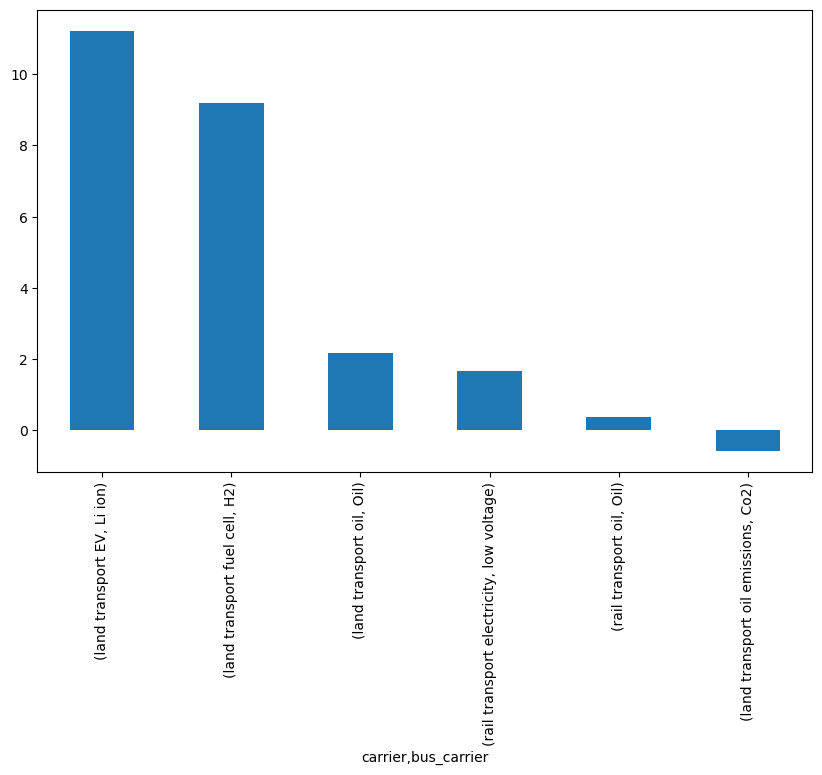

In [49]:
# Fix: Use get_level_values to filter MultiIndex by 'transport' in any level
energy_balance_load = n.statistics.energy_balance(comps='Load')
mask = energy_balance_load.index.to_frame().apply(lambda row: row.astype(str).str.contains('transport').any(), axis=1)
energy_balance_load[mask].divide(-1e6).sort_values(ascending=False).plot(kind='bar', figsize=(10, 6))

Analys the future generation capacity expansion of the energy system - bar chart

<Axes: title={'center': 'Generator capacity expansion in GW'}, xlabel='carrier'>

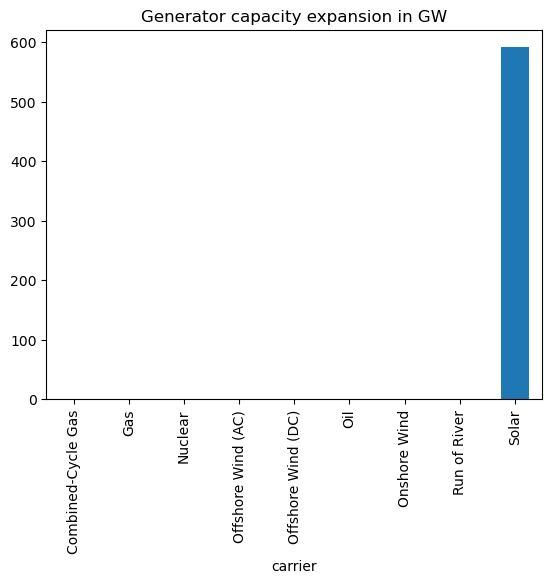

In [50]:
optimal_capacity = n.statistics.optimal_capacity(comps=["Generator"]).droplevel(0).div(1e3)
installed_capacity = n.statistics.installed_capacity(comps=["Generator"]).droplevel(0).div(1e3)
generation_capacity_expansion = optimal_capacity - installed_capacity
generation_capacity_expansion.drop(["load"], inplace=True)
generation_capacity_expansion.plot.bar(title="Generator capacity expansion in GW")

Plot the future generation capacity expansion of the energy system - tabular chart

In [51]:
generation_capacity_expansion # In GW

carrier
Combined-Cycle Gas    0.000000e+00
Gas                            NaN
Nuclear               0.000000e+00
Offshore Wind (AC)             NaN
Offshore Wind (DC)             NaN
Oil                            NaN
Onshore Wind          6.500000e-07
Run of River          0.000000e+00
Solar                 5.909099e+02
dtype: float64

Analyse the future energy generation of the energy system - bar chart view

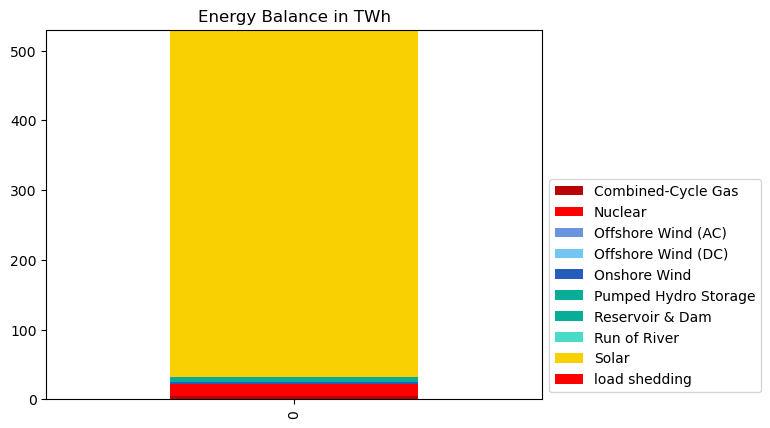

In [124]:
colors = {key.lower(): value.lower() for key, value in config["plotting"]["tech_colors"].items()}
nice_names = {value.lower(): key for key, value in config["plotting"]["nice_names"].items()}

rename_cols = {
    '-': 'Load',
    'load': 'load shedding',
}

energy_balance = (
    n.statistics.energy_balance()
    .loc[:, :, "AC"]
    .groupby("carrier")
    .sum()
    .div(1e6)
    .to_frame()
    .T
    .rename(columns=rename_cols)
)

# color-matching
color_list = []
for col in energy_balance.columns:
    original_name = col.lower()
    key_name = nice_names.get(original_name, original_name)
    color = colors.get(key_name.lower(), 'gray')
    color_list.append(color)


fig, ax = plt.subplots()
energy_balance.plot.bar(stacked=True, ax=ax, title="Energy Balance in TWh", color=color_list)
handles, labels = ax.get_legend_handles_labels()
nice_labels = [config["plotting"]["nice_names"].get(label, label) for label in energy_balance.columns]
ax.legend(handles, nice_labels, bbox_to_anchor=(1, 0), loc="lower left", title=None, ncol=1)

plt.show()

Analyse the future energy generation of the energy system - tabular view

In [125]:
n.statistics.energy_balance()/1e6 # In TWh

component  carrier                                  bus_carrier                            
Load       AC                                       low voltage                               -3.013741e+02
           H2                                       H2                                        -1.070000e+02
           H2 for shipping                          H2                                        -2.947231e+00
           Residential rural heat                   Residential rural heat                    -4.388836e+00
           Residential urban decentral heat         Residential urban decentral heat          -3.991048e+00
                                                                                                   ...     
Store      Residential urban decentral water tanks  Residential urban decentral water tanks   -5.619000e-08
           Services rural water tanks               Services rural water tanks                -5.629000e-08
           Services urban decentral water ta

## Analyse pv and wind potential - map view

In [126]:
solar = xr.open_dataset(solar_path)
wind = xr.open_dataset(onwind_path)

def plot_voronoi(n, carrier, voronoi, cmap, projection, title=None, filename=None):
    g = n.generators.loc[n.generators.carrier == carrier]
    br = gpd.read_file(f"{PARENT}resources/{scenario_name}/bus_regions/regions_{voronoi}.geojson").set_index("name")
    br_area = br.to_crs("ESRI:54009")
    br_area = br_area.geometry.area * 1e-6
    br["p_nom_max"] = g.groupby("bus").sum().p_nom_max / br_area

    fig, ax = plt.subplots(figsize=(8, 4), subplot_kw={"projection": projection})
    plt.rcParams.update({"font.size": 10})
    br.plot(
        ax=ax,
        column="p_nom_max",
        transform=ccrs.PlateCarree(),
        linewidth=0.25,
        edgecolor="k",
        cmap=cmap,
        vmin=0,
        vmax=br["p_nom_max"].max(),
        legend=True,
        legend_kwds={"label": r"potential density"},
    )
    ax.coastlines()
    ax.add_feature(cartopy.feature.BORDERS.with_scale("110m"))
    ax.set_extent(country_coordinates, crs=ccrs.PlateCarree()) 
    
    if title is not None:
        plt.title(title)

Plot wind energy potential

In [128]:
warnings.simplefilter(action='ignore', category=FutureWarning)
plot_voronoi(
    pypsa.Network(network_path),
    "onwind",
    "onshore",
    "Blues",
    ccrs.PlateCarree(),
    title="Onshore Wind Potential Density [MW/km2]",
)
warnings.simplefilter(action='default', category=FutureWarning)

Index(['transf_1_0', 'transf_1_1', 'transf_2_0', 'transf_2_1', 'transf_3_0',
       'transf_4_0', 'transf_5_0', 'transf_6_0', 'transf_8_0', 'transf_9_0',
       ...
       'transf_351_0', 'transf_352_0', 'transf_354_0', 'transf_359_0',
       'transf_361_0', 'transf_362_0', 'transf_369_0', 'transf_369_1',
       'transf_376_0', 'transf_417_0'],
      dtype='object', name='name', length=164)
Index(['transf_1_0', 'transf_1_1', 'transf_2_0', 'transf_2_1', 'transf_3_0',
       'transf_4_0', 'transf_5_0', 'transf_6_0', 'transf_8_0', 'transf_9_0',
       ...
       'transf_351_0', 'transf_352_0', 'transf_354_0', 'transf_359_0',
       'transf_361_0', 'transf_362_0', 'transf_369_0', 'transf_369_1',
       'transf_376_0', 'transf_417_0'],
      dtype='object', name='name', length=164)
Index(['transf_1_0', 'transf_1_1', 'transf_2_0', 'transf_2_1', 'transf_3_0',
       'transf_4_0', 'transf_5_0', 'transf_6_0', 'transf_8_0', 'transf_9_0',
       ...
       'transf_351_0', 'transf_352_0', 'transf_

NameError: name 'scenario_name' is not defined

Plot pv energy potential

In [129]:
warnings.simplefilter(action='ignore', category=FutureWarning)
plot_voronoi(
    pypsa.Network(network_path),
    "solar",
    "onshore",
    "OrRd",
    ccrs.PlateCarree(),
    title="Solar Photovoltaic Potential Density [MW/km2]",
)
warnings.simplefilter(action='default', category=FutureWarning)

Index(['transf_1_0', 'transf_1_1', 'transf_2_0', 'transf_2_1', 'transf_3_0',
       'transf_4_0', 'transf_5_0', 'transf_6_0', 'transf_8_0', 'transf_9_0',
       ...
       'transf_351_0', 'transf_352_0', 'transf_354_0', 'transf_359_0',
       'transf_361_0', 'transf_362_0', 'transf_369_0', 'transf_369_1',
       'transf_376_0', 'transf_417_0'],
      dtype='object', name='name', length=164)
Index(['transf_1_0', 'transf_1_1', 'transf_2_0', 'transf_2_1', 'transf_3_0',
       'transf_4_0', 'transf_5_0', 'transf_6_0', 'transf_8_0', 'transf_9_0',
       ...
       'transf_351_0', 'transf_352_0', 'transf_354_0', 'transf_359_0',
       'transf_361_0', 'transf_362_0', 'transf_369_0', 'transf_369_1',
       'transf_376_0', 'transf_417_0'],
      dtype='object', name='name', length=164)
Index(['transf_1_0', 'transf_1_1', 'transf_2_0', 'transf_2_1', 'transf_3_0',
       'transf_4_0', 'transf_5_0', 'transf_6_0', 'transf_8_0', 'transf_9_0',
       ...
       'transf_351_0', 'transf_352_0', 'transf_

NameError: name 'scenario_name' is not defined